In [21]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_excel("C:\\Users\\dunca\\OneDrive\\Desktop\\STAT 603\\FINAL EXAM\\EV_sales_data.xlsx")

data.head()


,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option,Units_Sold,Revenue
0,2023-07,Oceania,Toyota,i4,Crossover,62,6,High Income,No,260,3699780
1,2023-03,Oceania,Toyota,Leaf,Truck,70,19,High Income,Yes,347,7801424
2,2023-05,North America,Toyota,ID.5,Crossover,81,13,Middle Income,No,294,4813013
3,2023-02,Oceania,Tesla,Corolla EV,Truck,73,4,High Income,Yes,281,7484912
4,2023-10,North America,BYD,Leaf,Coupe,52,4,High Income,No,166,4025360


,Vehicle_Type,Count,Probability
0,Hatchback,178,0.335217
1,Truck,116,0.218456
2,SUV,73,0.137476
3,Coupe,61,0.114878
4,Sedan,53,0.099812
5,Crossover,50,0.094162


,Customer_Type,Count,Probability
0,Budget Conscious,136,0.256121
1,High Income,131,0.246704
2,Tech Enthusiast,115,0.216573
3,Eco-Conscious,86,0.161959
4,Middle Income,63,0.118644


,Region,Count,Probability
0,North America,154,0.290019
1,Oceania,136,0.256121
2,Africa,111,0.209040
3,Asia,63,0.118644
4,South America,36,0.067797
5,Europe,31,0.058380


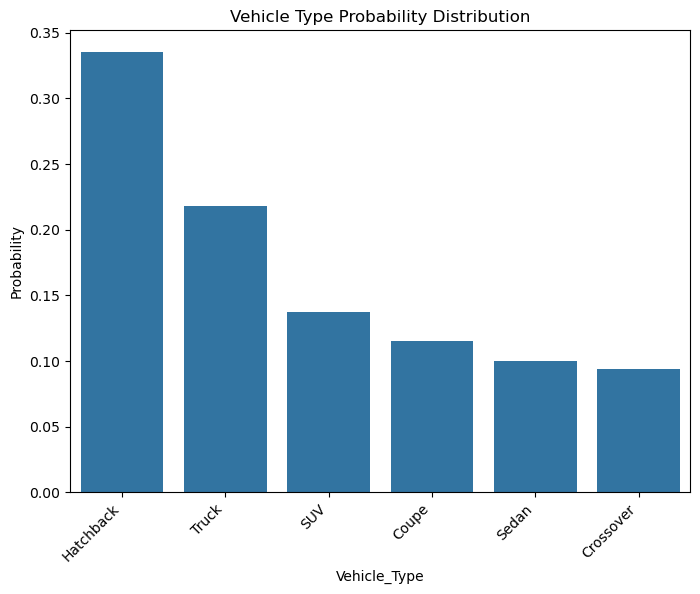

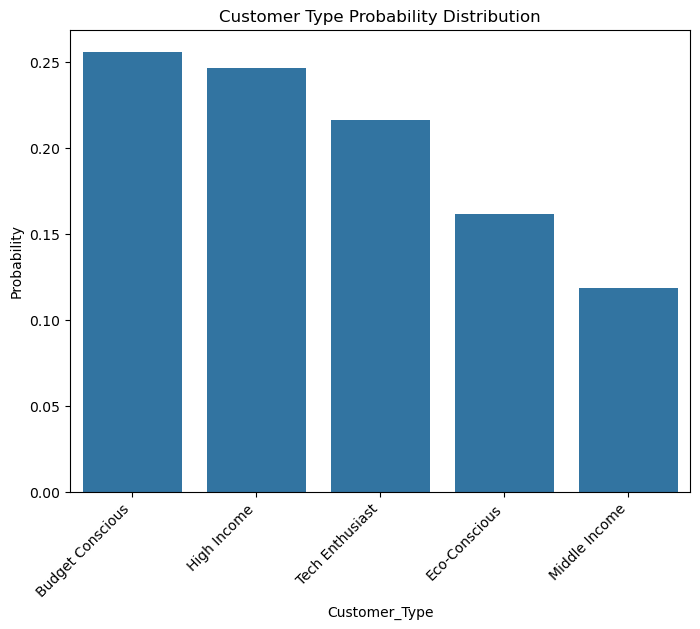

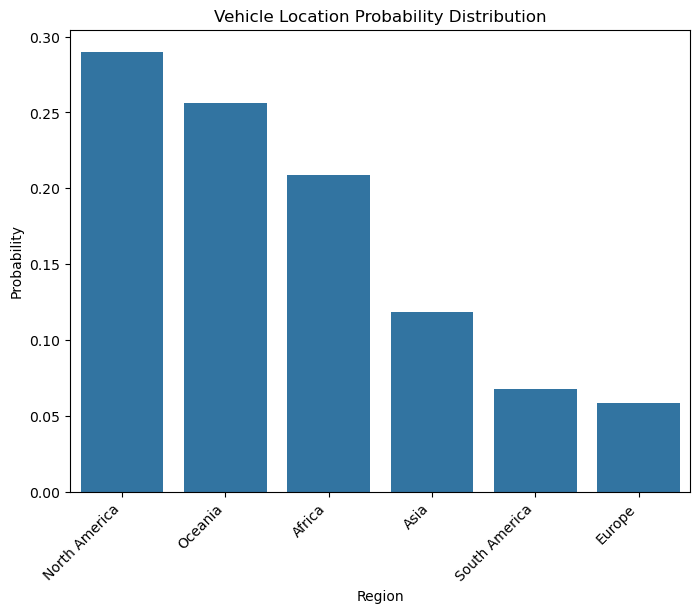

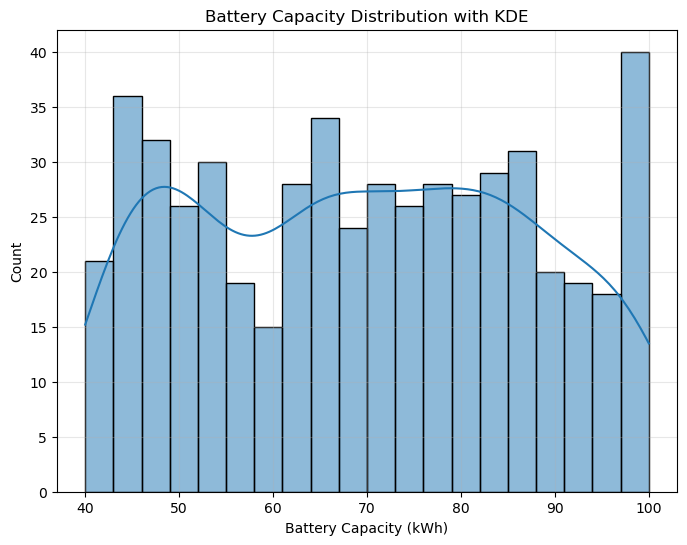

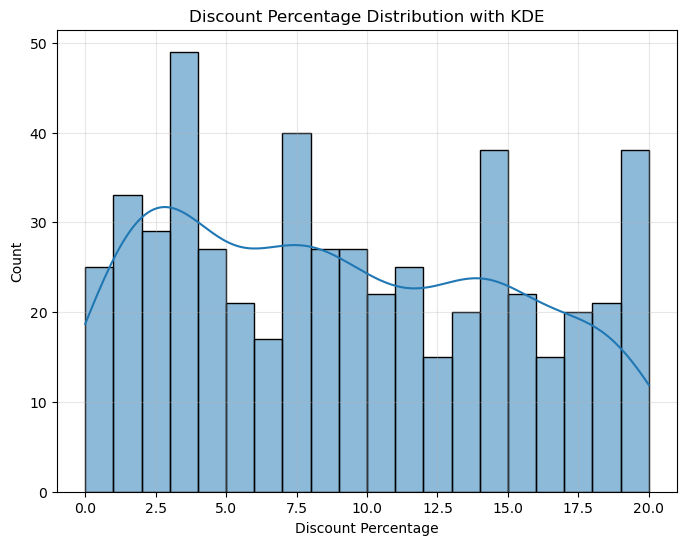

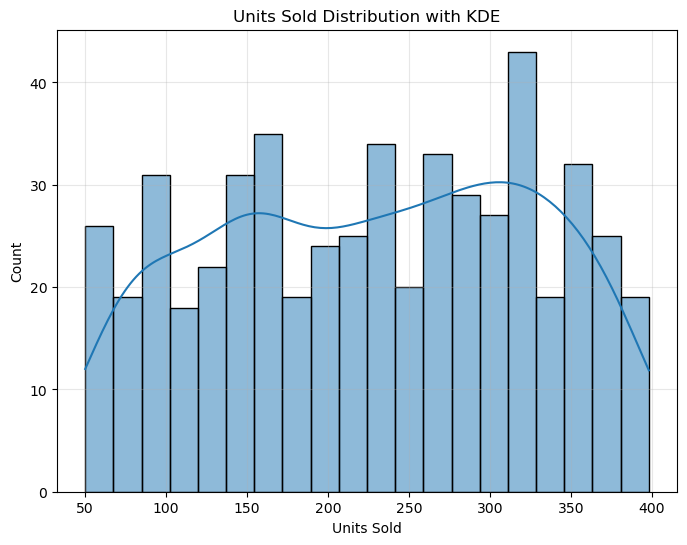

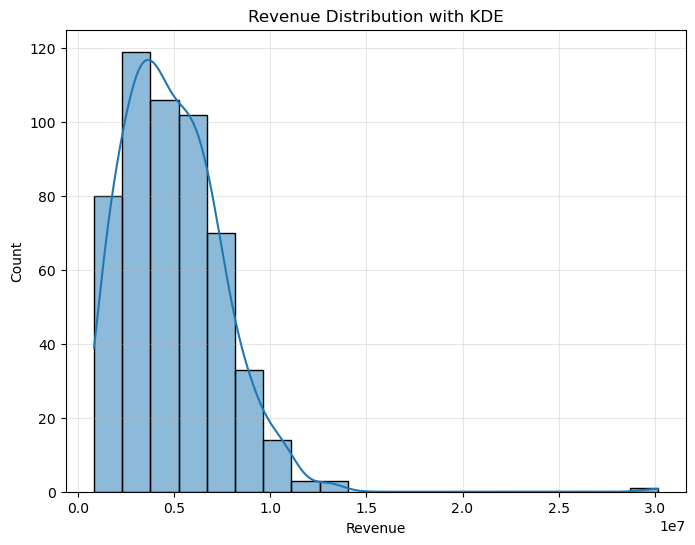

In [45]:
# Part A

# Probability distributions for categorical variables

vehicle_count = data['Vehicle_Type'].value_counts(dropna = False)
total_vehicle = len(data)
vehicle_prob = vehicle_count/total_vehicle

distribution_car_type = pd.DataFrame({'Count':vehicle_count, 'Probability':vehicle_prob}).sort_values('Count', ascending = False).reset_index()
distribution_car_type.columns = ['Vehicle_Type', 'Count', 'Probability']

display(distribution_car_type)

plt.figure(figsize=(8,6))
sb.barplot(x='Vehicle_Type', y='Probability', data=distribution_car_type)
plt.title('Vehicle Type Probability Distribution')
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.ylabel('Probability')
plt.show

customer_count = data['Customer_Segment'].value_counts(dropna = False)
total_customer = len(data)
customer_prob = customer_count/total_customer

distribution_customer_type = pd.DataFrame({'Count':customer_count, 'Probability':customer_prob}).sort_values('Count', ascending = False).reset_index()
distribution_customer_type.columns = ['Customer_Type', 'Count', 'Probability']

display(distribution_customer_type)

plt.figure(figsize=(8,6))
sb.barplot(x='Customer_Type', y='Probability', data=distribution_customer_type)
plt.title('Customer Type Probability Distribution')
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.ylabel('Probability')
plt.show

vehicle_location = data['Region'].value_counts(dropna = False)
total_location = len(data)
vehicle_location_prob = vehicle_location/total_location

distribution_car_location = pd.DataFrame({'Count':vehicle_location, 'Probability':vehicle_location_prob}).sort_values('Count', ascending = False).reset_index()
distribution_car_location.columns = ['Region', 'Count', 'Probability']

display(distribution_car_location)

plt.figure(figsize=(8,6))
sb.barplot(x='Region', y='Probability', data=distribution_car_location)
plt.title('Vehicle Location Probability Distribution')
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.ylabel('Probability')
plt.show

# Histograms of Continuous Variables

plt.figure(figsize=(8,6))
sb.histplot(data['Battery_Capacity_kWh'].dropna(), kde=True, bins=20)
plt.title('Battery Capacity Distribution with KDE')
plt.xlabel('Battery Capacity (kWh)')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
sb.histplot(data['Discount_Percentage'].dropna(), kde=True, bins=20)
plt.title('Discount Percentage Distribution with KDE')
plt.xlabel('Discount Percentage')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
sb.histplot(data['Units_Sold'].dropna(), kde=True, bins=20)
plt.title('Units Sold Distribution with KDE')
plt.xlabel('Units Sold')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
sb.histplot(data['Revenue'].dropna(), kde=True, bins=20)
plt.title('Revenue Distribution with KDE')
plt.xlabel('Revenue')
plt.grid(alpha=0.3)
plt.show()








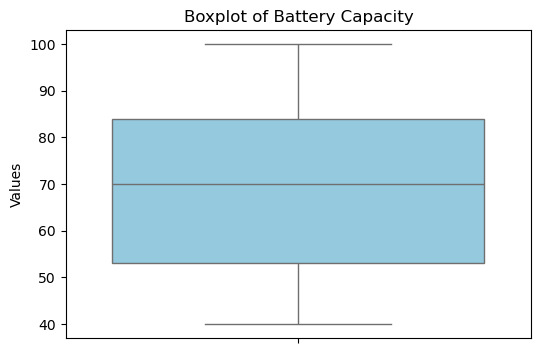

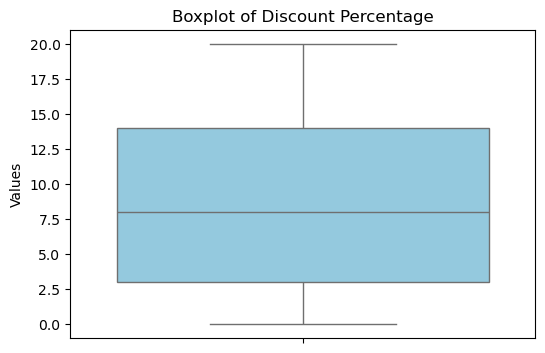

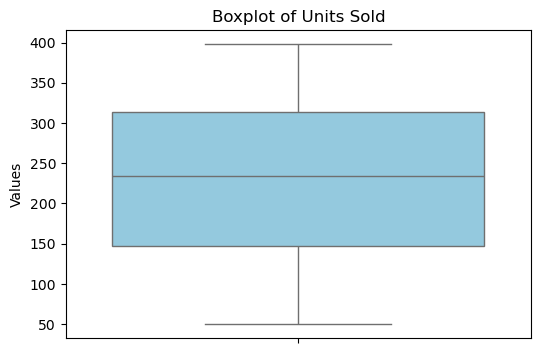

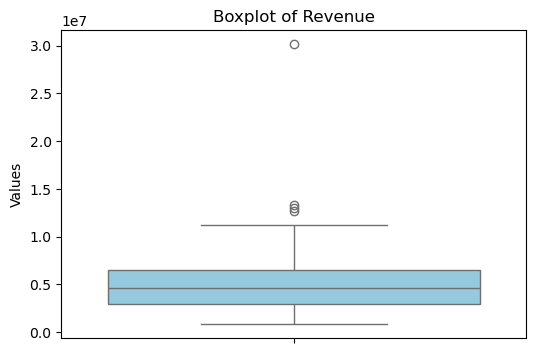

In [47]:
# Part B


plt.figure(figsize=(6, 4))
sb.boxplot(y=data['Battery_Capacity_kWh'], color='skyblue')
plt.title('Boxplot of Battery Capacity')
plt.ylabel('Values')
plt.show()

plt.figure(figsize=(6, 4))
sb.boxplot(y=data['Discount_Percentage'], color='skyblue')
plt.title('Boxplot of Discount Percentage')
plt.ylabel('Values')
plt.show()

plt.figure(figsize=(6, 4))
sb.boxplot(y=data['Units_Sold'], color='skyblue')
plt.title('Boxplot of Units Sold')
plt.ylabel('Values')
plt.show()

plt.figure(figsize=(6, 4))
sb.boxplot(y=data['Revenue'], color='skyblue')
plt.title('Boxplot of Revenue')
plt.ylabel('Values')
plt.show()

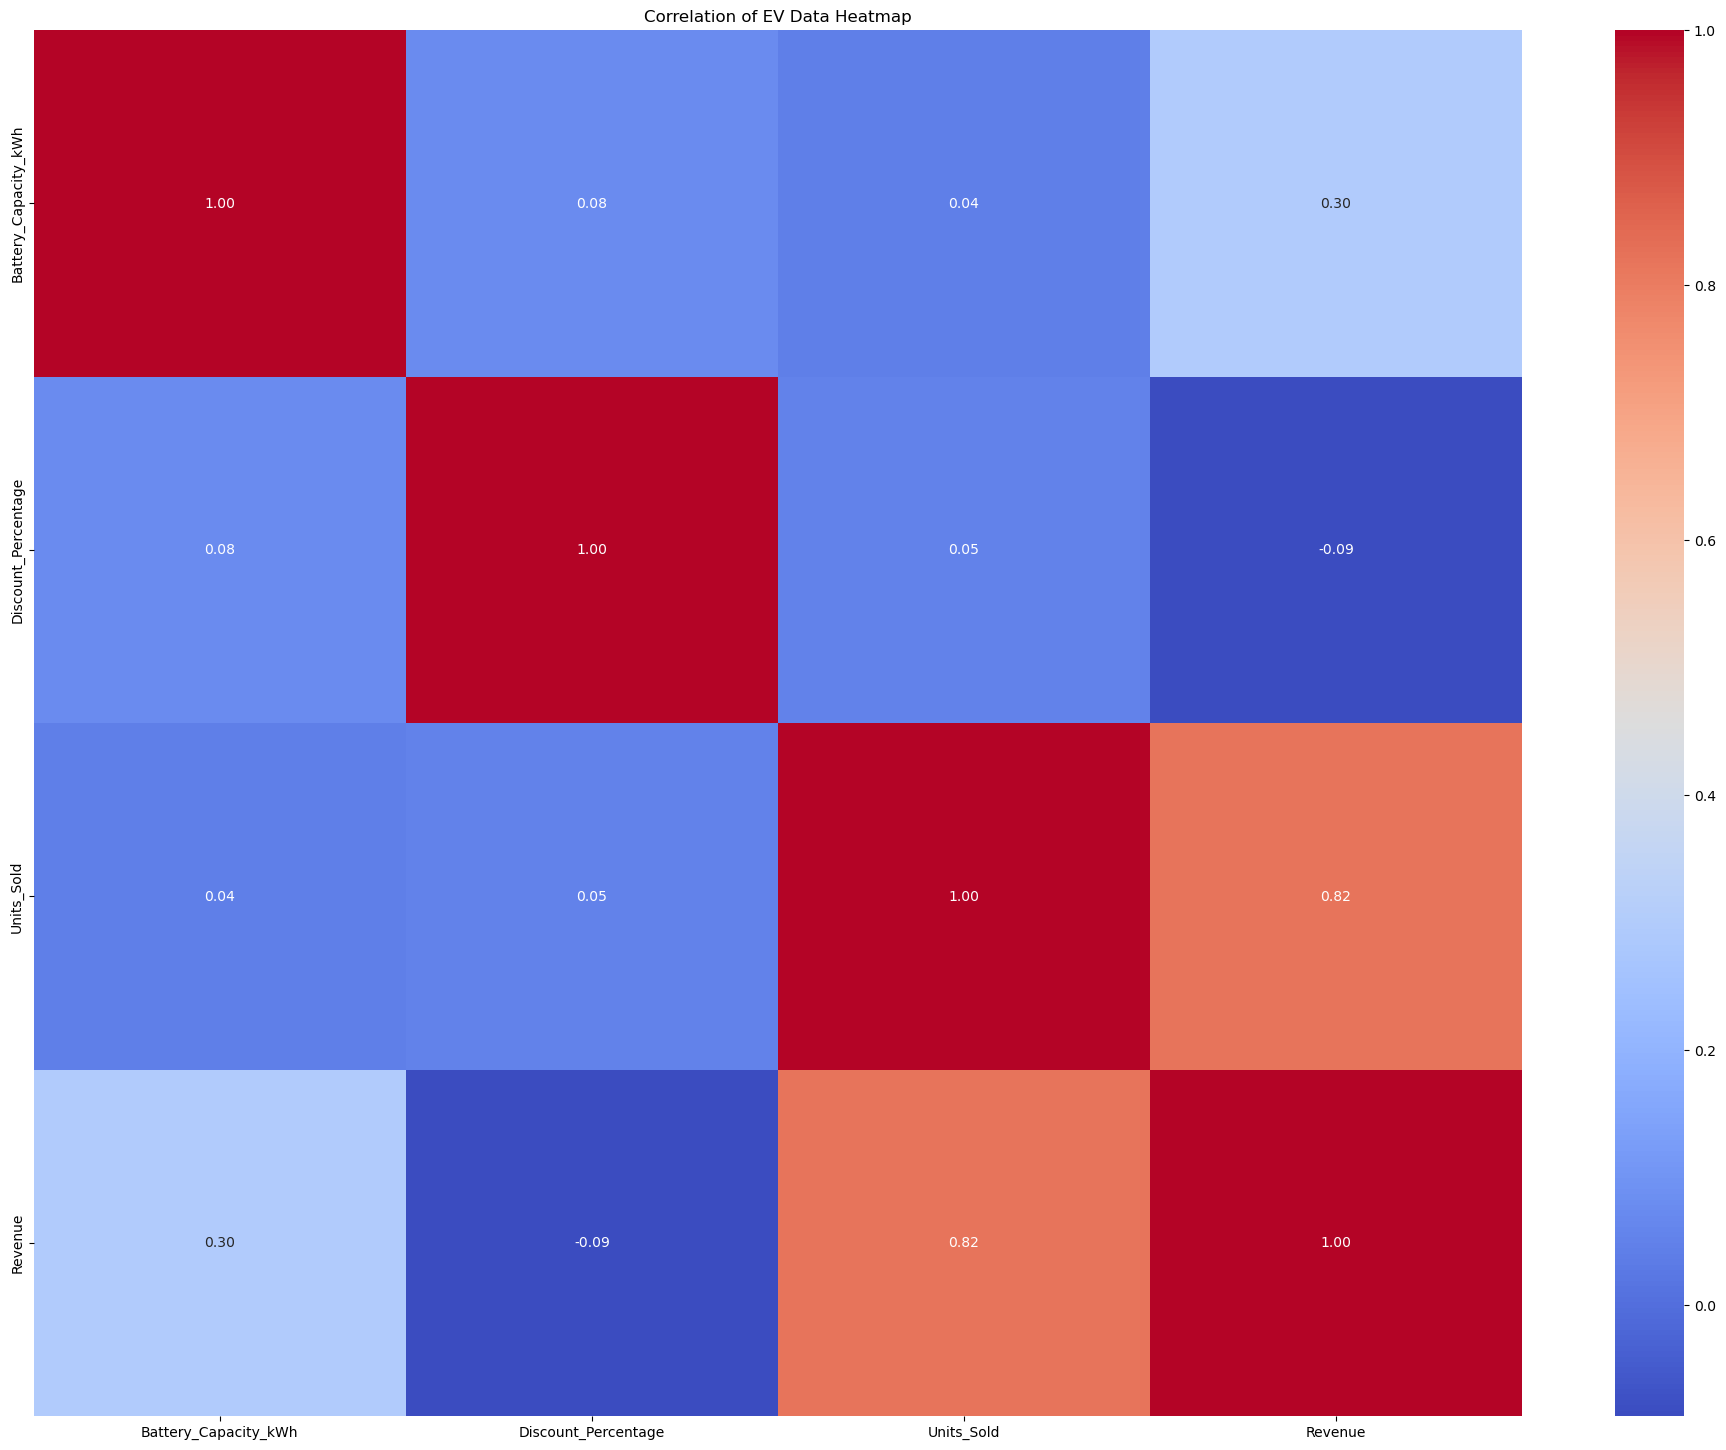

In [50]:
# Part C

ev_db = data.select_dtypes(include=[np.number])
plt.figure(figsize=(24, 18))
sb.heatmap(ev_db.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of EV Data Heatmap')
plt.show()

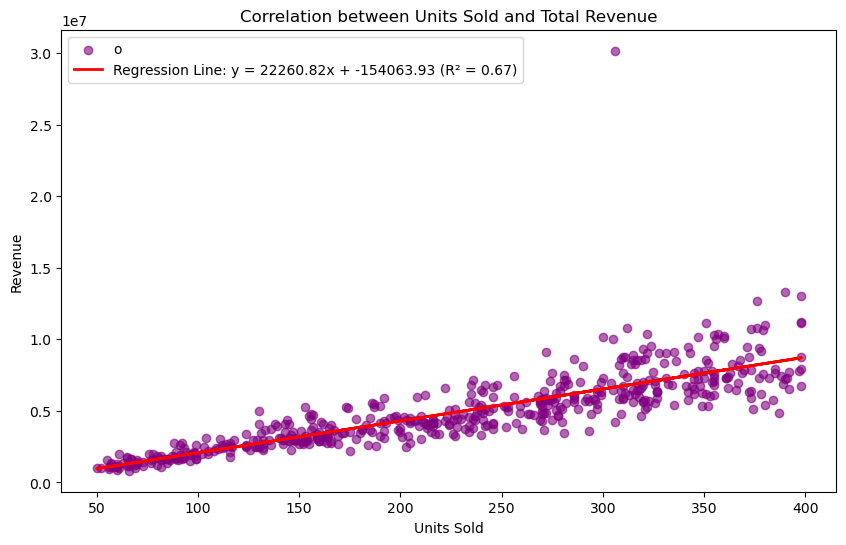

In [56]:
# Part D

# Use Units Sold and Revenue

from scipy import stats

x = data['Units_Sold']
y = data['Revenue']

plt.figure(figsize=(10,6))
plt.scatter(x,y, color = 'purple', alpha = 0.6, label = 'o')

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
regression_line = slope * x + intercept
plt.plot(x, regression_line, color='red', linewidth=2,label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f} (R² = {r_value**2:.2f})')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')
plt.title('Correlation between Units Sold and Total Revenue')
plt.legend()
plt.show()


In [ ]:
# Part E

# The data that I uploaded is a dataset that contains various metrics on 
# electric vehicles and where they were purchased. Interested findings were 
# that battery capacity was not normally distributed, meaning no one has found
# that optimum battery capacity to make the most revenue. As well as the most 
# typical buyer of the elctric cars have been budget conscious, which is weird, 
# since electric vehicles tend to be more expensive. 